Loaded:
X_train: (952, 37) | X_test: (239, 37)

=== Final Test Metrics ===
ROC-AUC: 0.925543
PR-AUC : 0.921393

Top 20 Features (Permutation Importance):
                                       feature  importance_mean  \
0                       Experience_Gap_LastOrg         0.229048   
1                                     JobTitle         0.038490   
2                            Job_Opportunities         0.030963   
3   Training_programs_ During_last_three_years         0.011805   
4                                   Allowances         0.007596   
5                      Get_ Deserved_Promotion         0.005259   
6                         Emotional_Commitment         0.005011   
7                                       Sector         0.003091   
8            Years_experience_lastorganization         0.002829   
9                                     OverTime         0.002563   
10                            Payment_Overtime         0.002008   
11                               MonthlySa

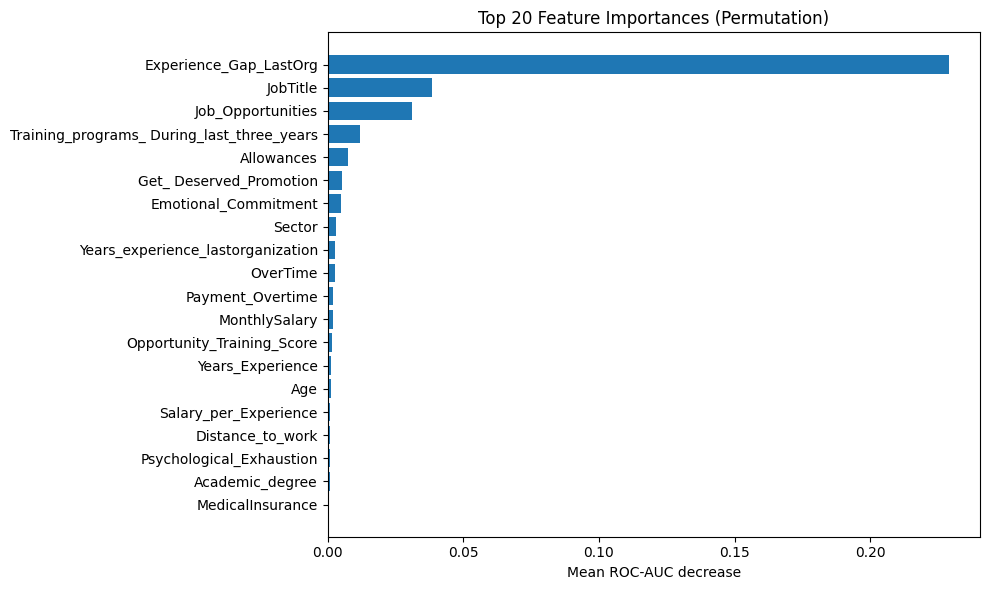

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# ======================================================
# 1) Paths
# ======================================================
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

# ======================================================
# 2) Load FE1 + Target Encoded data
# ======================================================
X_train = pd.read_csv(DATA_DIR / "X_train_fe1_target.csv")
X_test  = pd.read_csv(DATA_DIR / "X_test_fe1_target.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze().astype(int)
y_test  = pd.read_csv(DATA_DIR / "y_test.csv").squeeze().astype(int)

print("Loaded:")
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

# ======================================================
# 3) Train final XGBoost model
# ======================================================
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    n_estimators=800,
    learning_rate=0.01,
    max_depth=3,
    subsample=1.0,
    colsample_bytree=0.7,
    reg_lambda=1.0
)

xgb.fit(X_train, y_train)

proba = xgb.predict_proba(X_test)[:, 1]

test_roc = roc_auc_score(y_test, proba)
test_pr  = average_precision_score(y_test, proba)

print("\n=== Final Test Metrics ===")
print("ROC-AUC:", round(test_roc, 6))
print("PR-AUC :", round(test_pr, 6))

# ======================================================
# 4) Permutation Importance (Leakage-Safe)
# ======================================================
perm = permutation_importance(
    xgb,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print("\nTop 20 Features (Permutation Importance):")
print(perm_df.head(20))

perm_out = REPORTS_DIR / "feature_importance_fe1_target_permutation.csv"
perm_df.to_csv(perm_out, index=False)
print("\nSaved:", perm_out)

# ======================================================
# 5) XGBoost Built-in Gain Importance
# ======================================================
booster = xgb.get_booster()
gain_scores = booster.get_score(importance_type="gain")

gain_df = (
    pd.DataFrame({
        "feature": list(gain_scores.keys()),
        "gain": list(gain_scores.values())
    })
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)

gain_out = REPORTS_DIR / "feature_importance_fe1_target_gain.csv"
gain_df.to_csv(gain_out, index=False)

print("\nTop 20 Features (XGB Gain):")
print(gain_df.head(20))
print("\nSaved:", gain_out)

# ======================================================
# 6) Plot Top 20 Permutation Importance
# ======================================================
top_n = 20
plot_df = perm_df.head(top_n)

plt.figure(figsize=(10,6))
plt.barh(plot_df["feature"][::-1], plot_df["importance_mean"][::-1])
plt.xlabel("Mean ROC-AUC decrease")
plt.title("Top 20 Feature Importances (Permutation)")
plt.tight_layout()
plt.show()